
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** (laboratorio 4)

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [15]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

# Solución

##  Ejercicio 1

In [16]:
def Laplace2D_FDM(V_ini, tol=0.1): 
  Nmax = V_ini.shape[0] 
  V = V_ini.copy() 
  V1 = V_ini.copy() 
  dif = 1.0 
  while dif > tol: 
    for i in range(1, Nmax-1): 
      for j in range(1, Nmax-1): 
        V[i,j] = 0.25*(V1[i+1,j] + V1[i-1,j] + V1[i,j+1] + V1[i,j-1]) 
        
    dif = np.max(np.abs(V-V1)) 
    V1 = V.copy()
  return V

def grid(V_ini,x,y):
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] 
  
  return X,Y,Z

In [17]:
# Inciso punto 1

Nmax = 100 
# Inilización de matriz 
V_ini = np.zeros((Nmax, Nmax), float) #  Se crea una matriz de ceros
for k in range(0, Nmax):
  V_ini[k,0] = 100. # ESto es V(x,0)

# Creación de la

x = np.arange(0, Nmax-1, 1)
y = x

tol = 1e-3

# Solución mediante diferencias finitas 
V = Laplace2D_FDM(V_ini, tol)

X, Y, Z = grid(V, x, y)


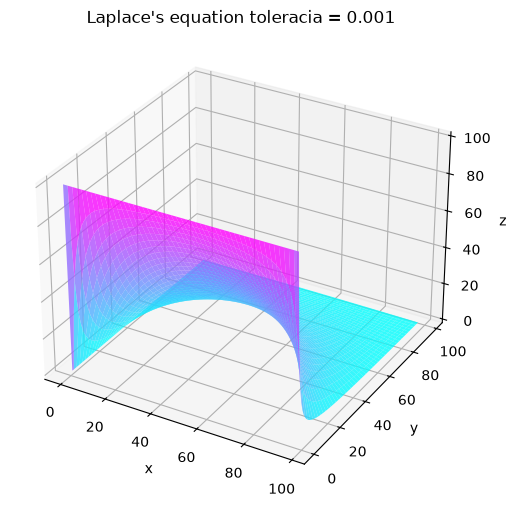

In [18]:

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title(f'Laplace\'s equation toleracia = {tol}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

**Justificación:**  Modifiqué la función original de manera que ahora uno de los parámetros sea la tolerancia en vez del número de iteraciones, y que esta sea el criterio utilizado para realizar el ciclo. Además, se inicializa dos variables: la variable `dif`, que permitirá cuantificar la diferencia entre cada paso del ciclo, y la cantidad de interacciones, que nos ayudará en caso de querer saber cuántas veces se realizó el ciclo. Una vez realizado el método de Jacobi, se calcula la diferencia entre los pasos antes y después de realizar el ciclo. Luego, se toma el valor máximo de la diferencia en valor absoluto, y este será el nuevo valor de comparación. El ciclo se detiene cuando esta diferencia se vuelve menor que el valor de tolerancia y, finalmente, se retorna la última matriz calculada junto con el número de interacciones realizadas.


In [19]:
#Inciso 2:  Series de Fourier



def Fourier(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 # VOltaje inicial
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)



def Fourier_tolerance( tol = 0.1,L=1):
 
  z = 0
  z1=0
  dif=1.0
  N=0
  coordx = np.linspace(0,L,100) # Número de puntos
  coordy = coordx
  x , y = np.meshgrid(coordx, coordy, indexing= 'ij') # pasar de 1D a 2D
  iteracion =0 
  while(dif >tol):
    iteracion +=1
    #Solo los valores impares por función sen()
    z = z + Fourier(x,y,((2*N)+1),L)
    dif = np.max(np.abs(z-z1)) 
    z1 = z.copy()
    N +=1
  return iteracion,x,y,z

In [20]:
tol_1  = 1e-4
N,x_1,y_1,z_1 = Fourier_tolerance(tol_1)

print(f" El número de iteraciones es:{N} y la toleración es: {tol_1}")

 El número de iteraciones es:50 y la toleración es: 0.0001


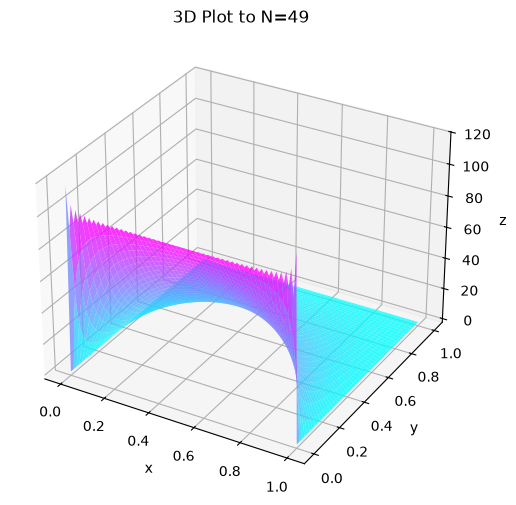

In [21]:

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x_1, y_1, z_1, cmap='cool', alpha=0.8)
ax.set_title('3D Plot to N=%.1d'%(N-1))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

In [22]:
# Comparación entre método de Diferencias finitas y Fourier

def solve_laplace_ejercicio1(N=50, tol=1e-4):
    V = np.zeros((N, N), float)
    V[:, -1] = 100.0  
    
    V_next = V.copy()
    dif = 1.0
    
    while dif > tol:
        for i in range(1, N-1):
            for j in range(1, N-1):
                V_next[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])
                
        dif = np.max(np.abs(V_next - V))
        V = V_next.copy()
        
    return V


def fourier_laplace(N, V0=100.0, tol=1e-4):
    # Coordenadas normalizadas de 0 a 1 (x/L y y/L)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    V_ana = np.zeros((N, N), float)
    
    # Extraemos solo el interior para evaluar la tolerancia y evitar el fenómeno de Gibbs 
    # en el borde y=1 donde la serie converge a una onda cuadrada abrupta.
    X_int = X[1:-1, 1:-1]
    Y_int = Y[1:-1, 1:-1]
    V_ana_int = np.zeros_like(X_int)
    
    n = 1
    terms_count = 0
    max_term_val = 1.0
    
    
    while max_term_val > tol:
        c = n * np.pi
        
        # Reformulación estable para evitar overflow en np.sinh() para n grande
        factor_Y = np.exp(c * (Y_int - 1)) * (1 - np.exp(-2 * c * Y_int)) / (1 - np.exp(-2 * c))
        
        # Cálculo del término de la serie
        term = (4 * V0 / (n * np.pi)) * np.sin(c * X_int) * factor_Y
        
        V_ana_int += term
        max_term_val = np.max(np.abs(term))
        
        n += 2 
        terms_count += 1
        
   
    V_ana[1:-1, 1:-1] = V_ana_int
    V_ana[:, -1] = V0 
    
    return V_ana, terms_count

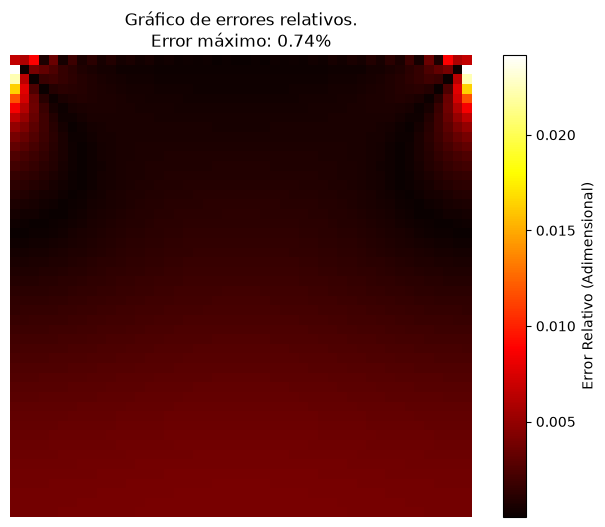

In [28]:
N = 50


# Ejecución
# --- Cálculo de Errores (Método de tu compañero) ---

eps = 1e-15 # valor auxiliar para evitar divisiones entre cero

# Eliminamos las fronteras debido a que pueden presentar errores por la naturaleza de la serie
V_fdm_int = V_num[1:-1, 1:-1]
V_anal_int = V_ana[1:-1, 1:-1]

# Cálculo de error relativo punto a punto
err_rel_matriz = np.abs(V_fdm_int - V_anal_int) / (np.abs(V_anal_int) + eps)

# Cálculo de error relativo máximo en porcentaje
err_rel_max = np.max(np.abs(V_fdm_int - V_anal_int)) / np.max(np.abs(V_anal_int)) * 100

# --- Gráfica de errores relativos ---
plt.figure(figsize=(8,6))
plt.imshow(err_rel_matriz.T, origin='lower', cmap='hot') # Añadí .T para mantener la orientación (x,y)
plt.title(f'Gráfico de errores relativos.\nError máximo: {err_rel_max:.2f}%')
plt.axis('off')

# Nota: Tu compañero etiquetó la barra como 'Potencial (V)', 
# pero al ser un error relativo, es adimensional. Lo he corregido aquí.
plt.colorbar(label='Error Relativo (Adimensional)') 
plt.show()


# Ejercicio 3 

In [24]:
def Laplace2D_Capacitor(Nmax, tol=0.1):
    # 1. Inicialización de la matriz de ceros
    V = np.zeros((Nmax, Nmax), float)
    
    # 2. Definición de las placas del capacitor (Condiciones de frontera)
    #  las placas en el centro de la cuadrícula
    p_pos = Nmax // 3      # Posición x de la placa positiva
    p_neg = 2 * Nmax // 3  # Posición x de la placa negativa
    y_ini = Nmax // 4      # Inicio y de las placas
    y_fin = 3 * Nmax // 4  # Fin y de las placas
    
    # el potencial inicial a las placas 
    V[y_ini:y_fin, p_pos] = 100.0
    V[y_ini:y_fin, p_neg] = -100.0
    
    V1 = V.copy()
    dif = 1.0
    
    # 3. Solución mediante diferencias finitas (Método de Jacobi)
    while dif > tol:
        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                # Solo actualizamos si el nodo NO pertenece a las placas
                # Esto mantiene el potencial de las placas constante
                en_placa_pos = (j == p_pos) and (y_ini <= i < y_fin)
                en_placa_neg = (j == p_neg) and (y_ini <= i < y_fin)
                
                if not (en_placa_pos or en_placa_neg):
                    V[i,j] = 0.25 * (V1[i+1,j] + V1[i-1,j] + V1[i,j+1] + V1[i,j-1])
                    
        dif = np.max(np.abs(V - V1))
        V1 = V.copy()
        
    return V

def Electric_Field(V, Nmax):
    # Inicializamos las componentes del campo eléctrico
    Ex = np.zeros((Nmax, Nmax), float)
    Ey = np.zeros((Nmax, Nmax), float)
    
    # FDM para el campo eléctrico (Diferencias finitas centrales)
    for i in range(1, Nmax-1):
        for j in range(1, Nmax-1):
            Ex[i,j] = -(V[i, j+1] - V[i, j-1]) / 2.0
            Ey[i,j] = -(V[i+1, j] - V[i-1, j]) / 2.0
            
    return Ex, Ey

<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_51907/1696256112.py:20: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Potencial Eléctrico $\phi$')


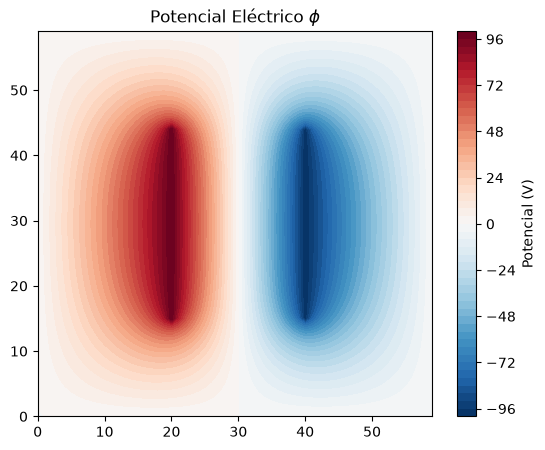

In [25]:
Nmax = 60
tol = 1e-3

# Cálculo numérico
V = Laplace2D_Capacitor(Nmax, tol)
Ex, Ey = Electric_Field(V, Nmax)

# Creación del grid para graficar
x = np.arange(0, Nmax)
y = np.arange(0, Nmax)
X, Y = np.meshgrid(x, y)

# Configuración de los gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Potencial usando contour como sugiere el laboratorio
plt.subplot(1, 2, 1)
plt.contourf(X, Y, V, levels=50, cmap='RdBu_r')
plt.colorbar(label='Potencial (V)')
plt.title('Potencial Eléctrico $\phi$')

# Gráfico 2: Campo Eléctrico



plt.show()

In [26]:
# --- 1. CONFIGURACIÓN Y CÁLCULO DEL POTENCIAL (CAPACITOR) ---
Nx = 100
Ny = 100
volt = 50

V = np.zeros((Nx, Ny), float)

# Definir la geometría de las placas del capacitor
# Usamos un grosor de d=10 y longitud l=20 como sugiere tu código
x_center = Nx // 2
y_center = Ny // 2
d_grid = 10 * Nx // 100
l_grid = 20 * Ny // 100

x_left = x_center - d_grid // 2
x_right = x_center + d_grid // 2
y_bottom = y_center - l_grid // 2
y_top = y_center + l_grid // 2

# Fijamos los potenciales de las placas
V[x_left, y_bottom:y_top] = volt
V[x_right, y_bottom:y_top] = -volt

# Para una malla 100x100, la vectorización es vital para ahorrar tiempo
dif = 1.0
tol_V = 1e-4
while dif > tol_V:
    V_new = V.copy()
    # Aplicamos Laplace vectorizado en el interior
    V_new[1:-1, 1:-1] = 0.25 * (V[2:, 1:-1] + V[:-2, 1:-1] + V[1:-1, 2:] + V[1:-1, :-2])
    
    # Mantenemos fijas las placas
    V_new[x_left, y_bottom:y_top] = volt
    V_new[x_right, y_bottom:y_top] = -volt
    
    dif = np.max(np.abs(V_new - V))
    V = V_new

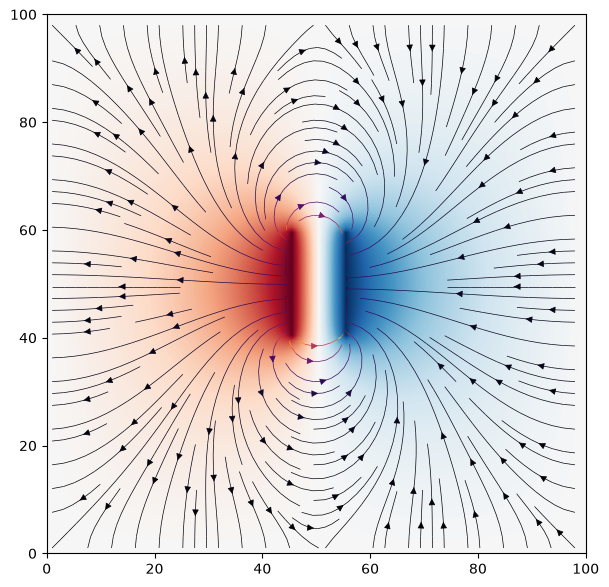

In [27]:
U = V.copy()

err = 1e-5
d = 10
l = 20
volt = 50
Nx = 100
Ny = 100
# GRID PARAMETERS
d_grid = d*Nx/100
l_grid = l*Ny/100

# Central derivative for E field
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]
#E[..., 0] es una sintaxis de indexación en NumPy para arrays multidimensionales.

# Interior grid coordinates matching E's shape (Nx-2, Ny-2)
x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
#ax.imshow(U.T, interpolation="bilinear", extent=[0, Nx, 0, Ny])
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny], interpolation="bilinear")

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()